### Task 1A — Confusion matrix e falsi positivi/negativi

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"  

In [2]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

DATA_DIR = "/code/HLTproject_code/data"
TARGET_NAMES = ["simple", "complex"]

test = pd.read_parquet(os.path.join(DATA_DIR, "test.parquet"))
y_test = test["is_original"].astype(int).values
print(f"Test set: {len(test)} righe | positivi (complesso): {y_test.sum()} | negativi (semplice): {(1 - y_test).sum()}")

Test set: 15078 righe | positivi (complesso): 7539 | negativi (semplice): 7539


In [3]:
def print_fpr_fnr(y_true, y_pred, name):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    print(f"--- {name} ---")
    print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"False Positive Rate (semplice classificata come complesso): {fpr:.3%}")
    print(f"False Negative Rate (complesso classificata come semplice): {fnr:.3%}")
    return cm

def plot_cm(cm, name, ax):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=TARGET_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues", values_format="d")
    ax.set_title(name)

## 1. Logistic Regression

Refit veloce della pipeline (`SimpleImputer` → `StandardScaler` → `LogisticRegression`) con il miglior `C` già trovato in `logistic_reg/eval_results.json`, poi predizione sul test set.

In [5]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

with open("logistic_cls/eval_results.json") as f:
    logreg_meta = json.load(f)
best_C = logreg_meta["best_params"]["logisticregression__C"]
thr    = logreg_meta["threshold"]
print(f"Miglior C: {best_C} | Soglia calibrata: {thr:.4f}")

train = pd.read_parquet(os.path.join(DATA_DIR, "train.parquet"))
feat_cols = [c for c in train.columns
             if c not in ("original_sentence_idx", "text", "score", "is_original")]

# rifà il fit con il C migliore (veloce, secondi)
logreg_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    LogisticRegression(max_iter=1000, C=best_C, random_state=42),
)
logreg_pipeline.fit(train[feat_cols], train["is_original"].astype(int))

logreg_probs = logreg_pipeline.predict_proba(test[feat_cols])[:, 1]
logreg_preds = (logreg_probs > thr).astype(int)

print(classification_report(y_test, logreg_preds, target_names=TARGET_NAMES, digits=3))

Miglior C: 10.0 | Soglia calibrata: 0.3964
              precision    recall  f1-score   support

      simple      0.804     0.629     0.706      7539
     complex      0.695     0.847     0.764      7539

    accuracy                          0.738     15078
   macro avg      0.750     0.738     0.735     15078
weighted avg      0.750     0.738     0.735     15078



In [6]:
cm_logreg = print_fpr_fnr(y_test, logreg_preds, "Logistic Regression")

--- Logistic Regression ---
TN=4743  FP=2796  FN=1154  TP=6385
False Positive Rate (semplice classificata come complesso): 37.087%
False Negative Rate (complesso classificata come semplice): 15.307%


## 2. BERTino (fine-tuned)

Inferenza dal checkpoint salvato.

In [7]:
from datasets import Dataset
from scipy.special import softmax
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

with open("bert_cls/eval_results.json") as f:
    bert_meta = json.load(f)
CHECKPOINT = bert_meta["checkpoint"]
print(f"Checkpoint: {CHECKPOINT}")

tok = AutoTokenizer.from_pretrained(CHECKPOINT)

def make_ds(d: pd.DataFrame) -> Dataset:
    ds = Dataset.from_pandas(
        d[["text", "is_original"]]
        .rename(columns={"is_original": "labels"})
        .assign(labels=lambda df: df["labels"].astype(int))
        .reset_index(drop=True)
    )
    return ds.map(lambda b: tok(b["text"], truncation=True, max_length=128), batched=True)

test_ds = make_ds(test)

bert_model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT)

trainer = Trainer(
    model=bert_model,
    args=TrainingArguments(
        output_dir="bert_cls",
        per_device_eval_batch_size=16,
        fp16=True,
        eval_accumulation_steps=8,
        report_to="none",
    ),
    processing_class=tok,
    data_collator=DataCollatorWithPadding(tok),
)

thr = bert_meta["threshold"]          # la soglia calibrata, dal JSON
print(f"Soglia calibrata: {thr:.4f}")

test_out = trainer.predict(test_ds)
test_logits = test_out.predictions[0] if isinstance(test_out.predictions, tuple) else test_out.predictions
test_probs  = softmax(test_logits, axis=-1)[:, 1]      # P(complesso)
bert_preds  = (test_probs > thr).astype(int)           # <-- invece di argmax(-1)

print(classification_report(y_test, bert_preds, target_names=TARGET_NAMES, digits=3))

/data/miniconda3/envs/hlt/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Checkpoint: /code/HLTproject_code/task_1A_complexity_prediction/bert_cls/lr_5e-05/checkpoint-2828


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 21825.66it/s]


Soglia calibrata: 0.5430


              precision    recall  f1-score   support

      simple      0.906     0.798     0.849      7539
     complex      0.820     0.917     0.866      7539

    accuracy                          0.858     15078
   macro avg      0.863     0.858     0.857     15078
weighted avg      0.863     0.858     0.857     15078



In [8]:
cm_bert = print_fpr_fnr(y_test, bert_preds, "BERTino")

--- BERTino ---
TN=6019  FP=1520  FN=625  TP=6914
False Positive Rate (semplice classificata come complesso): 20.162%
False Negative Rate (complesso classificata come semplice): 8.290%


## 3. Confronto

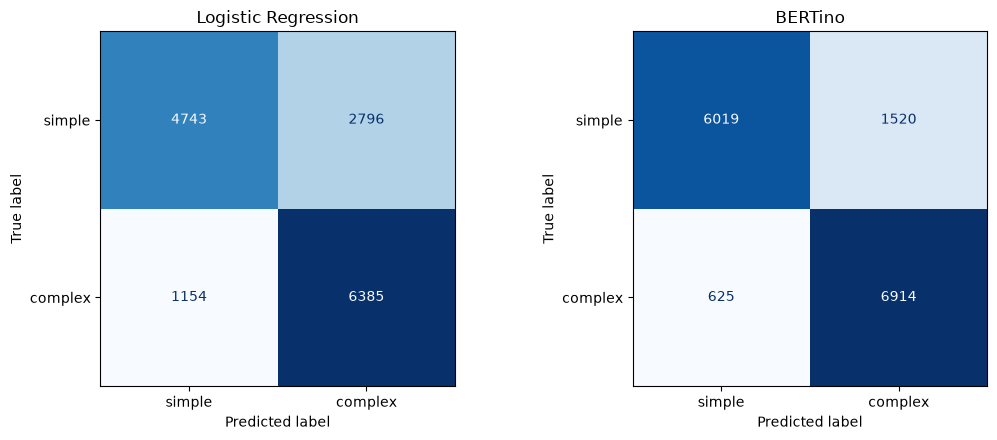

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
plot_cm(cm_logreg, "Logistic Regression", axes[0])
plot_cm(cm_bert, "BERTino", axes[1])
plt.tight_layout()
plt.show()
fig.savefig("confusion_matrices.pdf", bbox_inches="tight")

## 4. Esempi di errori (falsi positivi / falsi negativi)

Frasi *semplici* classificate come *complesse* (falsi positivi) e frasi *complesse* classificate come *semplici* (falsi negativi), per il modello BERTino.

In [11]:
err = test.reset_index(drop=True).copy()
err["pred"] = bert_preds
err["true"] = y_test

false_positives = err[(err["true"] == 0) & (err["pred"] == 1)]
false_negatives = err[(err["true"] == 1) & (err["pred"] == 0)]

print(f"Falsi positivi: {len(false_positives)}")
display(false_positives[["text", "score","pred", "true"]].head(10))

print(f"\nFalsi negativi: {len(false_negatives)}")
display(false_negatives[["text", "score","pred", "true"]].head(10))

Falsi positivi: 1520


,text,score,pred,true
7541,Fu eletto deputato per il Regno d'Italia nella...,0.182869,1,0
7543,"Wu, Brooklynn e i mercenari tornano all'elicot...",0.423758,1,0
7550,"Il ""Trione"" era un torrione posto sull'estremo...",0.369559,1,0
7554,Il freno è a quattro dischi con ABS per tutta ...,0.116800,1,0
7555,"Molte persone sono curiosi e si avvicinano, ma...",0.380420,1,0
7559,Anna cercò invano di ottenere la clemenza per ...,0.191777,1,0
7560,La sua carriera ha cominciato nel 1960 grazie ...,0.478895,1,0
7571,Il modello 1887 fu il primo fucile a ripetizio...,0.324873,1,0
7572,Sembra che il Buco del Piombo fosse già abitat...,0.413515,1,0
7573,È stata riportata la comparsa di sindrome neur...,0.365064,1,0



Falsi negativi: 625


,text,score,pred,true
16,Arthur's Seat e le Falesie di Salisbury limitr...,0.176739,0,1
44,Io è straordinariamente simile alla Luna per d...,0.708683,0,1
45,"Prima della modernizzazione della Corea, non c...",0.499847,0,1
48,La cantoria e la controcantoria furono realizz...,0.326377,0,1
55,L'Asama coprì di nuvole il cielo sopra Edo (l'...,0.439739,0,1
66,Questi mali sono stati disapprovati con forza ...,0.209374,0,1
69,Il fiore sembrerebbe una rosa bianca nascosto ...,0.076727,0,1
83,È stata usata come base per la selezione del B...,0.122070,0,1
95,La Chiesa di Gesù Cristo dei santi degli ultim...,0.496527,0,1
128,"Durante la riorganizzazione della Germania, l'...",0.179644,0,1
